# 21_Image 모델의 Input 분석하기

## 학습목표 
- 1. Faster R-CNN 모델의 구조를 통해 필요한 이미지와 라벨의 형태를 찾아낸다.    
- 2. 1을 내용을 기반으로, Custom Dataset을 작성한다.   

In [6]:
!pip install opencv-python
!pip install matplotlib 

  Using cached matplotlib-3.10.1-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.56.0-cp311-cp311-win_amd64.whl.metadata (103 kB)
  Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.1-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.1-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl (219 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.56.0-cp311-cp311-win_amd64.whl (2.2 MB)
Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl (71 kB)
Using cached pyparsing-3.2.1-py3-none-any.whl (107 kB)


In [2]:
import torch #훈련
from torch.utils.data import Dataset, DataLoader #커스텀 데이터셋을 만들기 위함
 
import os #로컬 컴퓨터에서 데이터셋을 불러오기 위해
import cv2 # 시각화 해서 표현하기 위함

In [4]:
# __함수__ : 던더 함수
class SimpleDataset(Dataset):
    #이 클래스의 객체가 생성되면 무조건 __init__ 함수가 동작하게 됨
    #기초 데이터, 함수 동작하도록 연결
    def __init__(self, t):
        self.t = t

    #데이터셋의 길이 반환
    #파이토치가 훈련을 할 때 len() -> 배치사이즈 대비 얼마나 데이터셋이 남아있는 지 체크할 때 씀
    def __len__(self):
        return self.t

    #데이터 + 라벨 -> 한 쌍을 뽑는 데 씀
    #idx = 몇 번째 데이터? 
    def __getitem__(self, idx):
        return torch.LongTensor([idx])

dataset = SimpleDataset(t=7)    
#이 데이터셋을 훈련에서 어떻게 활용할 것인가?       
dataloader = DataLoader(dataset = dataset ,   #어떤 데이터셋을 훈련에 쓸 거니?         
                       batch_size = 2, #데이터셋을 쪼개 배치로 만듦       
                       shuffle = True,    #데이터셋을 섞어주는(랜덤)       
                       drop_last = True)  #배치사이즈 만들고 남은 데이터 쓸거야?       

In [3]:
import os #로컬 컴퓨터에서 데이터셋을 불러오기 위해
import cv2 # 시각화 해서 표현하기 위함
import numpy as np #이미지 픽셀 데이터를 numpy 형태로 표현함
import json #개별 라벨을 읽어들어오게 함

import torch #훈련
from torch.utils.data import Dataset, DataLoader #커스텀 데이터셋을 만들기 위함
from torchvision import transforms #torchvision -> 딥러닝(이미지) 수행하는 클래스 이름 #transform 이미지를 조절
from PIL import Image #-> 이미지를 표현할 수 있는 파이썬 라이브러리 
import matplotlib.pyplot as plt

In [4]:
annotation_file = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29224.json'
image_path = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Images/upper_29224.png'

In [5]:
with open(annotation_file, 'r', encoding='utf-8') as f:
    annotations = json.load(f)

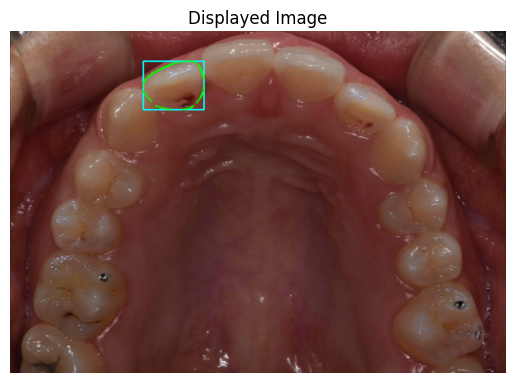

In [6]:
# x, y 좌표를 각각 추출
# p[0] 기준으로 오름차순 정렬
sorted_xs = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[0])

start_x = sorted_xs[0][0] 
end_x = sorted_xs[-1][0]

sorted_ys = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[1])
start_y = sorted_ys[0][1] 
end_y = sorted_ys[-1][1]

image_rgb = Image.open(image_path)
image = np.array(image_rgb)

#cv_image, start_point, end_point, color, thickness
result_image = cv2.rectangle(image, (start_x, start_y), (end_x, end_y), (0, 255, 255), 3)

sorted_points = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[0])
for x, y in sorted_points:
    result_image = cv2.circle(image, (x, y), 3, (0, 255, 0))

result_pil_image = Image.fromarray(result_image)

# 이미지 출력
plt.imshow(result_pil_image)
plt.axis('off')  # 축 제거
plt.title('Displayed Image')  # 제목 설정
plt.show()

### 어떤 형태의 데이터를 전달해야 하는가?

In [ ]:
# 타겟 딕셔너리 생성
target = {
    "boxes": boxes,
    "labels": labels,
    "image_id": image_id,
    "area": area,
    "iscrowd": iscrowd
}

In [7]:
class CustomData(Dataset):
    def __init__(self, image_list, label_list, transform):
        self.image_path = self.read_file_lines(image_list)
        self.label_path = self.read_file_lines(label_list)
        self.transform = transform
        
    def __len__(self):
        #if (이미지수 == 라벨수) return 이미지 수
        return len(self.image_path)

    #텐서 형태로 변환된 이미지를 돌려줌
    def __getitem__(self, idx):
        image = self.image_path[idx]
        image = Image.open(image)    #해당 경로에서 이미지를 읽어 옴

        if self.transform is not None:
            result = self.transform(image)

        box = self.get_label_data(self.label_path[idx])

        #타겟 딕셔너리 생성
        target = {
            'boxes' : box,
            #박스의 갯수만큼 라벨을 출력해주어야 함. 우리는 클래스는 하나이므로 그냥 활용해도 됨.
            'labels' : torch.zeros(len(box), dtype=torch.int64),
            'image_id' : torch.tensor([idx], dtype=torch.int64)
        }
        print(f'box:{box}, labels:{torch.zeros(len(box), dtype=torch.int64)}, image_id : {torch.tensor([idx], dtype=torch.int64)}')
        
        return image, target

    def get_label_data(self, lab):
        bounding_boxes = []
        with open(lab, 'r') as f:
            annotations = json.load(f)
            
        for i in range(len(annotations['tooth'])):
            if annotations['tooth'][i]['decayed'] == True:
                # x, y 좌표를 각각 추출
                # p[0] 기준으로 오름차순 정렬
                sorted_xs = sorted(annotations['tooth'][i]['segmentation'], key=lambda p: p[0])
                
                start_x = sorted_xs[0][0] 
                end_x = sorted_xs[-1][0]
                
                sorted_ys = sorted(annotations['tooth'][i]['segmentation'], key=lambda p: p[1])
                start_y = sorted_ys[0][1] 
                end_y = sorted_ys[-1][1]

                #x_min, y_min, x_max, y_max
                bounding_boxes.append([start_x, start_y, end_x, end_y])

        return bounding_boxes

    def read_file_lines(self, file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f]  # 개행 문자 제거 후 리스트로 변환
        return lines

## 커스텀 데이터셋을 만들기 위해 리스트의 일부를 파일로 만듦

In [18]:
json_list =  [os.path.join('C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/', x) 
                    for x in os.listdir('C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/')]

In [19]:
len(json_list)

30

In [21]:
import random

train_list = random.sample(json_list, int(len(json_list)*0.7))
valid_list = [x for x in json_list if x not in train_list]

In [25]:
print(train_list[:2])
print(valid_list[:2])

['C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29244.json', 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29249.json']
['C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29224.json', 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29227.json']


In [26]:
with open(f'./Datasets/Proj_1/train_list.txt', "w", encoding="utf-8") as f:
    for item in train_list:
        f.write(str(item) + "\n")  # 개행 문자 추가하여 한 줄씩 저장

In [27]:
with open(f'./Datasets/Proj_1/valid_list.txt', "w", encoding="utf-8") as f:
    for item in valid_list:
        f.write(str(item) + "\n")  # 개행 문자 추가하여 한 줄씩 저장

#### 이미지 리스트업

In [38]:
save_list = []
path = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Images/'
for i in train_list:
    file = i.split('/')[-1].split('.')[-2]
    filename = file + '.png'
    save = os.path.join(path, filename)
    save_list.append(save)

In [39]:
with open(f'./Datasets/Proj_1/train_image_list.txt', "w", encoding="utf-8") as f:
    for item in save_list:
        f.write(str(item) + "\n")  # 개행 문자 추가하여 한 줄씩 저장

In [40]:
savev_list = []
path = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Images/'
for i in valid_list:
    file = i.split('/')[-1].split('.')[-2]
    filename = file + '.png'
    save = os.path.join(path, filename)
    savev_list.append(save)

with open(f'./Datasets/Proj_1/valid_image_list.txt', "w", encoding="utf-8") as f:
    for item in savev_list:
        f.write(str(item) + "\n")  # 개행 문자 추가하여 한 줄씩 저장    